In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv('../dataset/Crime_Data_from_2020_to_Present.csv')
dataset.head(2)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628


In [3]:
print(dataset.shape)
dataset.info()


(1005198, 28)
<class 'pandas.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  str    
 2   DATE OCC        1005198 non-null  str    
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  str    
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  str    
 10  Mocodes         853438 non-null   str    
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   str    
 13  Vict Descent    860404 non-null   str    
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  str    
 16  Weapon Used Cd  327280 non-null  

In [4]:
def group_crimes(crime: str):
    crime_groups = {
        "Vehicle Crime": [
            "VEHICLE - STOLEN",
            "VEHICLE - ATTEMPT STOLEN",
            "BIKE - STOLEN",
            "BIKE - ATTEMPTED STOLEN",
            "BOAT - STOLEN",
            "DRIVING WITHOUT OWNER CONSENT (DWOC)",
            "VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)"
        ],

        "Theft": [
            "SHOPLIFTING-GRAND THEFT ($950.01 & OVER)",
            "SHOPLIFTING - PETTY THEFT ($950 & UNDER)",
            "SHOPLIFTING - ATTEMPT",
            "THEFT PLAIN - PETTY ($950 & UNDER)",
            "THEFT PLAIN - ATTEMPT",
            "THEFT, PERSON",
            "THEFT FROM PERSON - ATTEMPT",
            "PICKPOCKET",
            "PICKPOCKET, ATTEMPT",
            "PURSE SNATCHING",
            "PURSE SNATCHING - ATTEMPT",
            "TILL TAP - GRAND THEFT ($950.01 & OVER)",
            "TILL TAP - PETTY ($950 & UNDER)",
            "DRUNK ROLL",
            "DRUNK ROLL - ATTEMPT"
        ],

        "Property Crime": [
            "BURGLARY",
            "BURGLARY, ATTEMPTED",
            "BURGLARY FROM VEHICLE",
            "BURGLARY FROM VEHICLE, ATTEMPTED",
            "ARSON",
            "VANDALISM - MISDEAMEANOR ($399 OR UNDER)",
            "VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)",
            "TRESPASSING",
            "PROWLER",
            "ILLEGAL DUMPING"
        ],

        "Robbery": [
            "ROBBERY",
            "ATTEMPTED ROBBERY"
        ],

        "Fraud": [
            "THEFT OF IDENTITY",
            "BUNCO, GRAND THEFT",
            "BUNCO, PETTY THEFT",
            "BUNCO, ATTEMPT",
            "COUNTERFEIT",
            "EMBEZZLEMENT, GRAND THEFT ($950.01 & OVER)",
            "EMBEZZLEMENT, PETTY THEFT ($950 & UNDER)",
            "DOCUMENT FORGERY / STOLEN FELONY",
            "DOCUMENT WORTHLESS ($200.01 & OVER)",
            "DOCUMENT WORTHLESS ($200 & UNDER)",
            "CREDIT CARDS, FRAUD USE ($950.01 & OVER)",
            "CREDIT CARDS, FRAUD USE ($950 & UNDER",
            "GRAND THEFT / INSURANCE FRAUD",
            "DEFRAUDING INNKEEPER/THEFT OF SERVICES, $950 & UNDER",
            "DEFRAUDING INNKEEPER/THEFT OF SERVICES, OVER $950.01"
        ],

        "Weapons Offense": [
            "BRANDISH WEAPON",
            "DISCHARGE FIREARMS/SHOTS FIRED",
            "SHOTS FIRED AT INHABITED DWELLING",
            "SHOTS FIRED AT MOVING VEHICLE, TRAIN OR AIRCRAFT",
            "WEAPONS POSSESSION/BOMBING",
            "REPLICA FIREARMS(SALE,DISPLAY,MANUFACTURE OR DISTRIBUTE)",
            "FIREARMS RESTRAINING ORDER (FIREARMS RO)",
            "FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)",
            "BOMB SCARE"
        ],

        "Sex Crime": [
            "RAPE, FORCIBLE",
            "RAPE, ATTEMPTED",
            "ORAL COPULATION",
            "SEXUAL PENETRATION W/FOREIGN OBJECT",
            "SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W/ FRGN OBJ",
            "BATTERY WITH SEXUAL CONTACT",
            "INDECENT EXPOSURE",
            "LEWD CONDUCT",
            "PEEPING TOM",
            "SODOMY/SEXUAL CONTACT B/W PENIS OF ONE PERS TO ANUS OTH",
            "CHILD PORNOGRAPHY",
            "LEWD/LASCIVIOUS ACTS WITH CHILD",
            "INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)",
            "BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM"
        ],

        "Child Abuse": [
            "CRM AGNST CHLD (13 OR UNDER) (14-15 & SUSP 10 YRS OLDER)",
            "CHILD ABUSE (PHYSICAL) - SIMPLE ASSAULT",
            "CHILD ABUSE (PHYSICAL) - AGGRAVATED ASSAULT",
            "CHILD NEGLECT (SEE 300 W.I.C.)",
            "CHILD STEALING",
            "CHILD ANNOYING (17YRS & UNDER)",
            "CHILD ABANDONMENT"
        ],

        "Kidnapping": [
            "KIDNAPPING",
            "KIDNAPPING - GRAND ATTEMPT",
            "FALSE IMPRISONMENT"
        ],

        "Human Trafficking": [
            "PIMPING",
            "PANDERING",
            "HUMAN TRAFFICKING - COMMERCIAL SEX ACTS",
            "HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE"
        ],

        "Court Violation": [
            "VIOLATION OF COURT ORDER",
            "VIOLATION OF RESTRAINING ORDER",
            "VIOLATION OF TEMPORARY RESTRAINING ORDER",
            "CONTEMPT OF COURT",
            "SEX OFFENDER REGISTRANT OUT OF COMPLIANCE"
        ],

        "Homicide": [
            "CRIMINAL HOMICIDE",
            "MANSLAUGHTER, NEGLIGENT"
        ],

        "Threats/Harassment": [
            "CRIMINAL THREATS - NO WEAPON DISPLAYED",
            "THREATENING PHONE CALLS/LETTERS",
            "LETTERS, LEWD  -  TELEPHONE CALLS, LEWD",
            "STALKING"
        ],

        "Public Order": [
            "DISTURBING THE PEACE",
            "RESISTING ARREST",
            "FAILURE TO DISPERSE",
            "INCITING A RIOT",
            "CONSPIRACY",
            "DISRUPT SCHOOL",
            "FALSE POLICE REPORT",
            "RECKLESS DRIVING",
            "FAILURE TO YIELD",
            "OTHER MISCELLANEOUS CRIME"
        ]
    }

    crime = str(crime).strip().upper()

    for category, crimes in crime_groups.items():
        if crime in crimes:
            return category

    return "Other"

In [5]:
dataset['Crime_type'] = dataset['Crm Cd Desc'].apply(group_crimes)

In [6]:
df = dataset.copy()

In [7]:
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Crime_type
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506,Vehicle Crime
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628,Property Crime
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002,Vehicle Crime
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,Theft
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130,Vehicle Crime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895,Vehicle Crime
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923,Vehicle Crime
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074,Robbery
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922,Vehicle Crime


In [8]:
Underage_sex_crimes=df[(df['Vict Age'] < 18) & (df['Crime_type'] == 'Sex Crime')]

In [9]:
Underage_sex_crimes.sample(4)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Crime_type
632151,241906893,3/18/2024 0:00,1/1/2022 0:00,600,19,Mission,1918,2,810,"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...",...,Juv Other,810.0,NaN,NaN,NaN,13700 FOOTHILL BL,NaN,34.3087,-118.4319,Sex Crime
796323,231411933,6/6/2023 0:00,6/6/2023 0:00,1540,14,Pacific,1428,2,860,BATTERY WITH SEXUAL CONTACT,...,Invest Cont,860.0,NaN,NaN,NaN,10800 WOODBINE ST,NaN,34.0248,-118.4150,Sex Crime
591634,222017873,12/3/2022 0:00,11/28/2022 0:00,1700,20,Olympic,2046,1,121,"RAPE, FORCIBLE",...,Juv Arrest,121.0,860.0,998.0,NaN,800 S BERENDO ST,NaN,34.0577,-118.2941,Sex Crime
19513,200806931,3/4/2020 0:00,3/4/2020 0:00,1900,8,West LA,895,2,810,"SEX,UNLAWFUL(INC MUTUAL CONSENT, PENETRATION W...",...,Invest Cont,810.0,NaN,NaN,NaN,3200 MOTOR AV,NaN,34.0310,-118.4110,Sex Crime


In [10]:
Underage_sex_crimes.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,4.056000e+03,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,2913.000000,4056.000000,1332.000000,268.000000,8.00000,4056.000000,4056.000000
mean,2.205763e+08,1200.128698,11.967456,1242.848619,1.599852,684.871795,12.999753,451.534024,400.785445,683.036243,871.088589,991.328358,975.87500,34.044883,-118.219902
std,1.269972e+07,681.889566,6.003117,601.115623,0.489989,284.344407,4.343824,201.413459,32.203278,283.947175,83.886777,31.733033,62.57895,1.202774,4.155263
min,2.001051e+08,1.000000,1.000000,101.000000,1.000000,121.000000,-2.000000,101.000000,101.000000,121.000000,626.000000,815.000000,821.00000,0.000000,-118.656100
25%,2.110049e+08,800.000000,7.000000,756.750000,1.000000,810.000000,12.000000,501.000000,400.000000,810.000000,812.000000,998.000000,998.00000,34.006150,-118.445800
50%,2.213007e+08,1200.000000,12.000000,1283.000000,2.000000,814.000000,14.000000,501.000000,400.000000,812.000000,817.500000,998.000000,998.00000,34.065200,-118.329750
75%,2.312239e+08,1700.000000,17.000000,1775.000000,2.000000,850.000000,16.000000,502.000000,400.000000,850.000000,998.000000,998.000000,998.00000,34.197600,-118.278200
max,2.519042e+08,2359.000000,21.000000,2198.000000,2.000000,932.000000,17.000000,957.000000,515.000000,932.000000,998.000000,999.000000,998.00000,34.326500,0.000000


In [11]:
# removal of outliers

Underage_sex_crimes=Underage_sex_crimes[Underage_sex_crimes['Vict Age'] > 0]
Underage_sex_crimes.shape

(3853, 29)

In [12]:
Underage_sex_crimes.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,3.853000e+03,3853.000000,3853.000000,3853.000000,3853.000000,3853.000000,3853.000000,3853.000000,2821.000000,3853.000000,1300.000000,267.000000,8.00000,3853.000000,3853.000000
mean,2.206225e+08,1197.283416,12.061251,1252.253828,1.588632,680.708539,13.685180,455.297690,400.803261,678.779393,868.463846,991.299625,975.87500,34.077250,-118.335580
std,1.264131e+07,684.981212,5.980097,598.807003,0.492145,287.115495,3.236166,196.154826,31.995721,286.674450,82.693826,31.789133,62.57895,0.563588,1.910076
min,2.001051e+08,1.000000,1.000000,101.000000,1.000000,121.000000,2.000000,101.000000,101.000000,121.000000,626.000000,815.000000,821.00000,0.000000,-118.656100
25%,2.110098e+08,800.000000,7.000000,773.000000,1.000000,810.000000,13.000000,501.000000,400.000000,810.000000,812.000000,998.000000,998.00000,34.003800,-118.446300
50%,2.213048e+08,1200.000000,13.000000,1321.000000,2.000000,810.000000,15.000000,501.000000,400.000000,810.000000,815.000000,998.000000,998.00000,34.063500,-118.330600
75%,2.312245e+08,1700.000000,17.000000,1781.000000,2.000000,850.000000,16.000000,502.000000,400.000000,850.000000,998.000000,998.000000,998.00000,34.197600,-118.278300
max,2.519042e+08,2359.000000,21.000000,2198.000000,2.000000,932.000000,17.000000,957.000000,515.000000,932.000000,998.000000,998.000000,998.00000,34.326500,0.000000


In [13]:
Features=Underage_sex_crimes[['LON' , 'LAT']]

In [14]:
from numpy import radians

features_rad = radians(Features)
features_rad

,LON,LAT
674,-2.064728,0.593253
1042,-2.064423,0.592791
1425,-2.064063,0.594414
1445,-2.064402,0.593429
1796,-2.063093,0.595742
...,...,...
1004964,-2.064601,0.589008
1005071,-2.064515,0.588679
1005087,-2.067198,0.598163
1005142,-2.068622,0.597688


In [19]:
from sklearn.cluster import OPTICS

noise = []
clusters = []
largest_cl_size = []
median_cl_size = []
# distance = []
min_samples = []


for ms in range(5,30):
    clusterer = OPTICS(
        # 5 Km Distances apart from the clusters
        min_samples=ms,
        # Since the data is the Location (radians)
        metric='haversine',
        
    )

    labels = clusterer.fit_predict(features_rad)
    sizes = pd.Series(labels).value_counts()
    
    noise.append(sizes.loc[-1] / len(labels) * 100)
    clusters.append(len(sizes) - 1)
    largest_cl_size.append(sizes.drop(-1).max())
    median_cl_size.append(sizes.drop(-1).median())
    distance.append(distances)
    min_samples.append(ms)


pd.DataFrame(
{
    "Noise" : noise,
    "n_cluster" : clusters,
    "largest_cl_size" : largest_cl_size,
    "median_cl_size" : median_cl_size,
    # "distance" : distance,
    "min_sample" : min_samples
}
)


C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encounter

,Noise,n_cluster,largest_cl_size,median_cl_size,min_sample
0,38.126135,288,35,8.0,5
1,42.356605,221,35,9.0,6
2,41.733714,192,37,10.0,7
3,47.132105,152,48,12.0,8
4,51.518297,124,38,13.0,9
5,52.686219,107,48,15.0,10
6,54.840384,92,50,17.0,11
7,56.942642,80,48,18.5,12
8,59.563976,68,62,20.5,13
9,59.589930,60,59,24.0,14


In [23]:
minsamp_df=pd.DataFrame(
    {
        "Noise" : noise,
        "n_cluster" : clusters,
        "largest_cl_size" : largest_cl_size,
        "median_cl_size" : median_cl_size,
        # "distance" : distance,
        "min_sample" : min_samples
    }
)

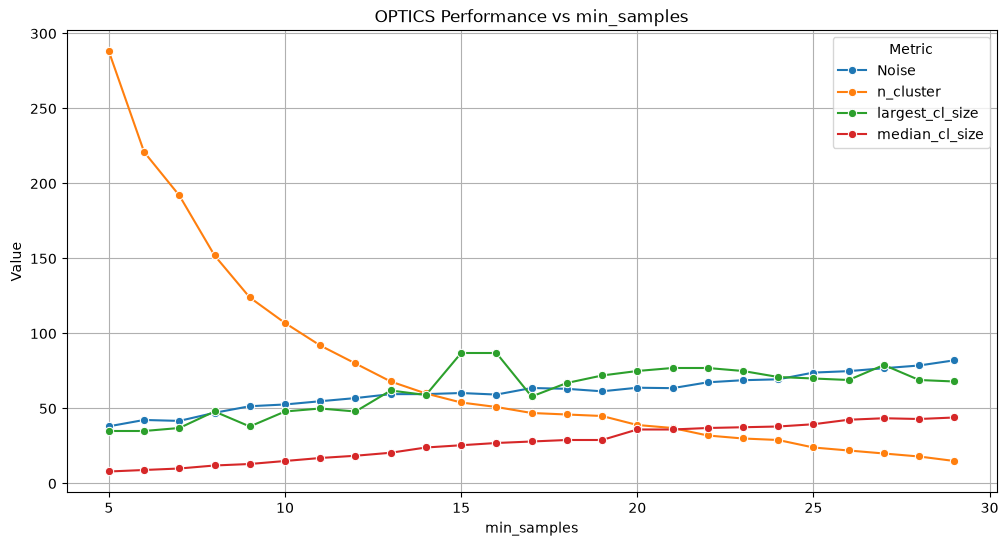

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = minsamp_df.melt(
    id_vars="min_sample",
    value_vars=[
        "Noise",
        "n_cluster",
        "largest_cl_size",
        "median_cl_size"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=plot_df,
    x="min_sample",
    y="Value",
    hue="Metric",
    marker="o"
)

plt.title("OPTICS Performance vs min_samples")
plt.xlabel("min_samples")
plt.ylabel("Value")
plt.grid(True)
plt.legend(title="Metric")

plt.show()

In [32]:
# from the Visualisation

# Extracting the Mid - High Crime hotspot with the Min samples : 15

mid_crime_hotspot = OPTICS(
    # 15 crime Hotspot to be considered mid crime hotspot
    min_samples=15,
    # Since the data is the Location (radians)
    metric='haversine',
)
mid_labels = mid_crime_hotspot.fit_predict(features_rad)

C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


In [33]:
mid_crime_hotspot = Underage_sex_crimes.copy()
mid_crime_hotspot['Labels'] = mid_labels

In [38]:
mid_crime_hotspot['Labels'].nunique()

# 54 clusters and a Noise 

55

In [44]:
# Removal of the Noise to create a mask as the Noise isnt a real cluster

In [84]:
mask = mid_labels != -1

In [85]:
from sklearn.metrics import davies_bouldin_score , silhouette_score
davies_bouldin_score(features_rad[mask], mid_labels[mask])  , silhouette_score(features_rad[mask],mid_labels[mask])

(0.4832728362755891, 0.6218368022456431)

In [86]:
from sklearn.metrics import calinski_harabasz_score
calinski_harabasz_score(features_rad[mask]  , mid_labels[mask])

13805.402450296328

In [45]:
# Remarkable Evaluation

In [63]:
sizes = pd.Series(mid_labels)
largest_clusters = (
    sizes[sizes != -1]
    .value_counts()
    .head(10)
    .index
)

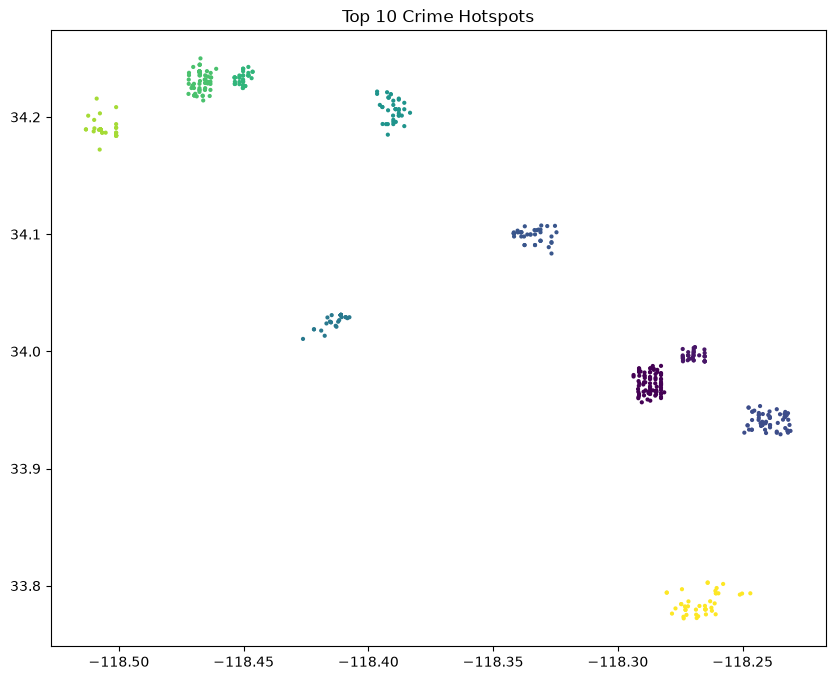

In [64]:
mask = np.isin(mid_labels, largest_clusters)

plt.figure(figsize=(10,8))

plt.scatter(
    np.degrees(features_rad.loc[mask, "LON"]),
    np.degrees(features_rad.loc[mask, "LAT"]),
    c=mid_labels[mask],
    s=4
)

plt.title("Top 10 Crime Hotspots")
plt.show()

Plotting top 10 clusters

In [110]:
import folium
import numpy as np
import pandas as pd

plot_df = features_rad.copy()
plot_df["LAT"] = np.degrees(plot_df["LAT"])
plot_df["LON"] = np.degrees(plot_df["LON"])
plot_df["cluster"] = mid_labels

largest_clusters = (
    plot_df["cluster"]
    .value_counts()
    .drop(-1)
    .head(10)
    .index
)

colors = [
    "red","blue","green","purple","orange",
    "darkred","cadetblue","darkgreen","pink","black"
]

m = folium.Map(
    location=[plot_df["LAT"].mean(), plot_df["LON"].mean()],
    zoom_start=10
)

for cluster_id, color in zip(largest_clusters, colors):

    cluster_data = plot_df[
        plot_df["cluster"] == cluster_id
    ]

    for _, row in cluster_data.iterrows():

        folium.CircleMarker(
            location=[row["LAT"], row["LON"]],
            radius=2,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"Cluster {cluster_id}"
        ).add_to(m)

m.save("top10_optics_clusters.html")
m

In [68]:
# High / Extreme Crime 

In [93]:
# from the Visualisation

# Extracting the Mid - High Crime hotspot with the Min samples : 15

extreme_crime = OPTICS(
    # 15 crime Hotspot to be considered mid crime hotspot
    min_samples=20,
    # Since the data is the Location (radians)
    metric='haversine',
)
high_labels = extreme_crime.fit_predict(features_rad)

C:\Users\apsan\Documents\Unsupervised_projects\Crime\Lib\site-packages\sklearn\cluster\_optics.py:1084: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


In [99]:
pd.Series(high_labels).nunique()

40

In [100]:
pd.Series(high_labels).value_counts(normalize=True)

-1     0.638464
 3     0.019465
 22    0.015572
 7     0.015572
 6     0.013496
 30    0.013496
 12    0.012977
 9     0.011420
 37    0.011420
 26    0.011160
 11    0.010901
 1     0.010641
 31    0.010382
 35    0.010122
 10    0.010122
 8     0.009862
 17    0.009603
 29    0.009603
 19    0.009343
 18    0.009343
 4     0.009343
 23    0.009084
 2     0.009084
 24    0.008565
 0     0.008046
 36    0.007267
 32    0.007267
 33    0.007267
 14    0.007008
 27    0.006488
 38    0.006229
 21    0.006229
 15    0.006229
 16    0.005969
 34    0.005710
 20    0.005710
 25    0.005450
 5     0.005450
 28    0.005450
 13    0.005191
Name: proportion, dtype: float64

In [96]:
# Creating a mask for the noise coverup

In [101]:
high_mask = high_labels != -1

In [105]:
from sklearn.metrics import davies_bouldin_score , silhouette_score
davies_bouldin_score(features_rad[high_mask], high_labels[high_mask]) 

0.5583598566336508

In [106]:
silhouette_score(features_rad[high_mask],high_labels[high_mask])

0.6152256422876253

In [107]:
calinski_harabasz_score(features_rad[high_mask],high_labels[high_mask])

15727.962644957019

In [103]:
# determines the higher crime locations

In [112]:
import folium
import numpy as np
import pandas as pd

plot_df = features_rad.copy()
plot_df["LAT"] = np.degrees(plot_df["LAT"])
plot_df["LON"] = np.degrees(plot_df["LON"])
plot_df["cluster"] = high_labels

largest_clusters = (
    plot_df["cluster"]
    .value_counts()
    .drop(-1)
    .head(10)
    .index
)

colors = [
    "red","blue","green","purple","orange",
    "darkred","cadetblue","darkgreen","pink","black"
]

m = folium.Map(
    location=[plot_df["LAT"].mean(), plot_df["LON"].mean()],
    zoom_start=10
)

for cluster_id, color in zip(largest_clusters, colors):

    cluster_data = plot_df[
        plot_df["cluster"] == cluster_id
    ]

    for _, row in cluster_data.iterrows():

        folium.CircleMarker(
            location=[row["LAT"], row["LON"]],
            radius=2,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"Cluster {cluster_id}"
        ).add_to(m)

m.save("top10_concerntrated_sexcrime_underage.html")
m

End